# Process Performance Map

Visualizes model prediction performance overlaid on a process map.

- **Start node**: How many cases start with each activity
- **Node color**: Overall accuracy when predicting from this activity
- **Edge color**: Accuracy for this specific transition (green = high, red = low)
- **Edge label**: correct/total predictions

In [1]:
# Setup
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))
if str(_current / 'src') not in sys.path:
    sys.path.insert(0, str(_current / 'src'))

import torch
from src.interpretability.config.bpic17_config import CONFIG
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation
from src.interpretability.visualization.process_performance_map import ProcessPerformanceMap

print(f"Dataset: {CONFIG.dataset_name}")

Dataset: BPIC17


In [2]:
# === TEST MODE CONFIGURATION ===
# Set TEST_MODE = True to run on a subset of cases for faster iteration
TEST_MODE = False
MAX_CASES = 1000  # Number of cases to use in test mode

print(f"Test mode: {TEST_MODE}" + (f" (max {MAX_CASES} cases)" if TEST_MODE else ""))

Test mode: False


In [3]:
# Load model and data
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
device = torch.device('cpu')
model = model.to(device)

test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)

eval_helper = Evaluation(
    model=model,
    dataset=test_dataset,
    concept_name=CONFIG.concept_name,
    growing_num_values=CONFIG.growing_num_values,
    all_cat=CONFIG.all_cat,
    all_num=CONFIG.all_num
)

print(f"Loaded {len(test_dataset)} samples")
print(f"Available cases: {len(eval_helper.cases)}")

Data set categories:  ([('concept:name', 28, {'A_Accepted': 1, 'A_Cancelled': 2, 'A_Complete': 3, 'A_Concept': 4, 'A_Create Application': 5, 'A_Denied': 6, 'A_Incomplete': 7, 'A_Pending': 8, 'A_Submitted': 9, 'A_Validating': 10, 'EOS': 11, 'O_Accepted': 12, 'O_Cancelled': 13, 'O_Create Offer': 14, 'O_Created': 15, 'O_Refused': 16, 'O_Returned': 17, 'O_Sent (mail and online)': 18, 'O_Sent (online only)': 19, 'W_Assess potential fraud': 20, 'W_Call after offers': 21, 'W_Call incomplete files': 22, 'W_Complete application': 23, 'W_Handle leads': 24, 'W_Personal Loan collection': 25, 'W_Shortened completion ': 26, 'W_Validate application': 27}), ('Action', 7, {'Created': 1, 'Deleted': 2, 'EOS': 3, 'Obtained': 4, 'Released': 5, 'statechange': 6}), ('org:resource', 151, {'EOS': 1, 'User_1': 2, 'User_10': 3, 'User_100': 4, 'User_101': 5, 'User_102': 6, 'User_103': 7, 'User_104': 8, 'User_105': 9, 'User_106': 10, 'User_107': 11, 'User_108': 12, 'User_109': 13, 'User_11': 14, 'User_110': 15, 'U

In [4]:
# Collect predictions
ppm = ProcessPerformanceMap(
    model=model,
    test_dataset=test_dataset,
    eval_helper=eval_helper,
    activity_key=CONFIG.concept_name,
    device=device
)

# Apply test mode: limit to subset of cases
if TEST_MODE:
    case_names = list(eval_helper.cases.keys())[:MAX_CASES]
    print(f"Test mode: using {len(case_names)} of {len(eval_helper.cases)} cases")
else:
    case_names = None  # Use all cases

ppm.collect_predictions(show_progress=True, case_names=case_names)

Collected 233080 predictions
Found 155 unique transitions


In [ ]:
# --- Overall accuracy summary ---
from collections import Counter, defaultdict
import pandas as pd

preds = ppm.predictions
n_total = len(preds)
n_correct = sum(1 for p in preds if p.correct)
overall = n_correct / n_total if n_total else 0.0
print(f'Overall next-activity accuracy: {n_correct}/{n_total} = {overall:.4f} ({overall*100:.2f}%)')

# Per prefix-length
by_plen = defaultdict(lambda: {'total': 0, 'correct': 0})
for p in preds:
    by_plen[p.prefix_length]['total'] += 1
    by_plen[p.prefix_length]['correct'] += int(p.correct)
rows = [{'prefix_length': pl, 'correct': v['correct'], 'total': v['total'],
         'accuracy': v['correct'] / v['total']}
        for pl, v in sorted(by_plen.items())]
print('\nPer prefix-length:')
print(pd.DataFrame(rows).to_string(index=False))

# Mean confidence (softmax argmax prob at the predicted class)
mean_conf = sum(p.confidence for p in preds) / n_total if n_total else 0.0
print(f'\nMean top-1 confidence: {mean_conf*100:.2f}%')


In [5]:
# Create activity name mapping
label_dict = ppm.get_activity_label_dict()
activity_name_map = {str(idx): name for name, idx in label_dict.items()}

print("Activity mapping:")
for idx_str in sorted(activity_name_map.keys(), key=lambda x: int(x) if x.isdigit() else 0):
    print(f"  {idx_str}: {activity_name_map[idx_str]}")

Activity mapping:
  1: A_Accepted
  2: A_Cancelled
  3: A_Complete
  4: A_Concept
  5: A_Create Application
  6: A_Denied
  7: A_Incomplete
  8: A_Pending
  9: A_Submitted
  10: A_Validating
  11: EOS
  12: O_Accepted
  13: O_Cancelled
  14: O_Create Offer
  15: O_Created
  16: O_Refused
  17: O_Returned
  18: O_Sent (mail and online)
  19: O_Sent (online only)
  20: W_Assess potential fraud
  21: W_Call after offers
  22: W_Call incomplete files
  23: W_Complete application
  24: W_Handle leads
  25: W_Personal Loan collection
  26: W_Shortened completion 
  27: W_Validate application


## Process Map

Filtered out 0 rare activities (< 10 occurrences)
Filtered out 54 rare directly-follows edges (< 10 occurrences)
Remaining: 26 activities, 111 edges


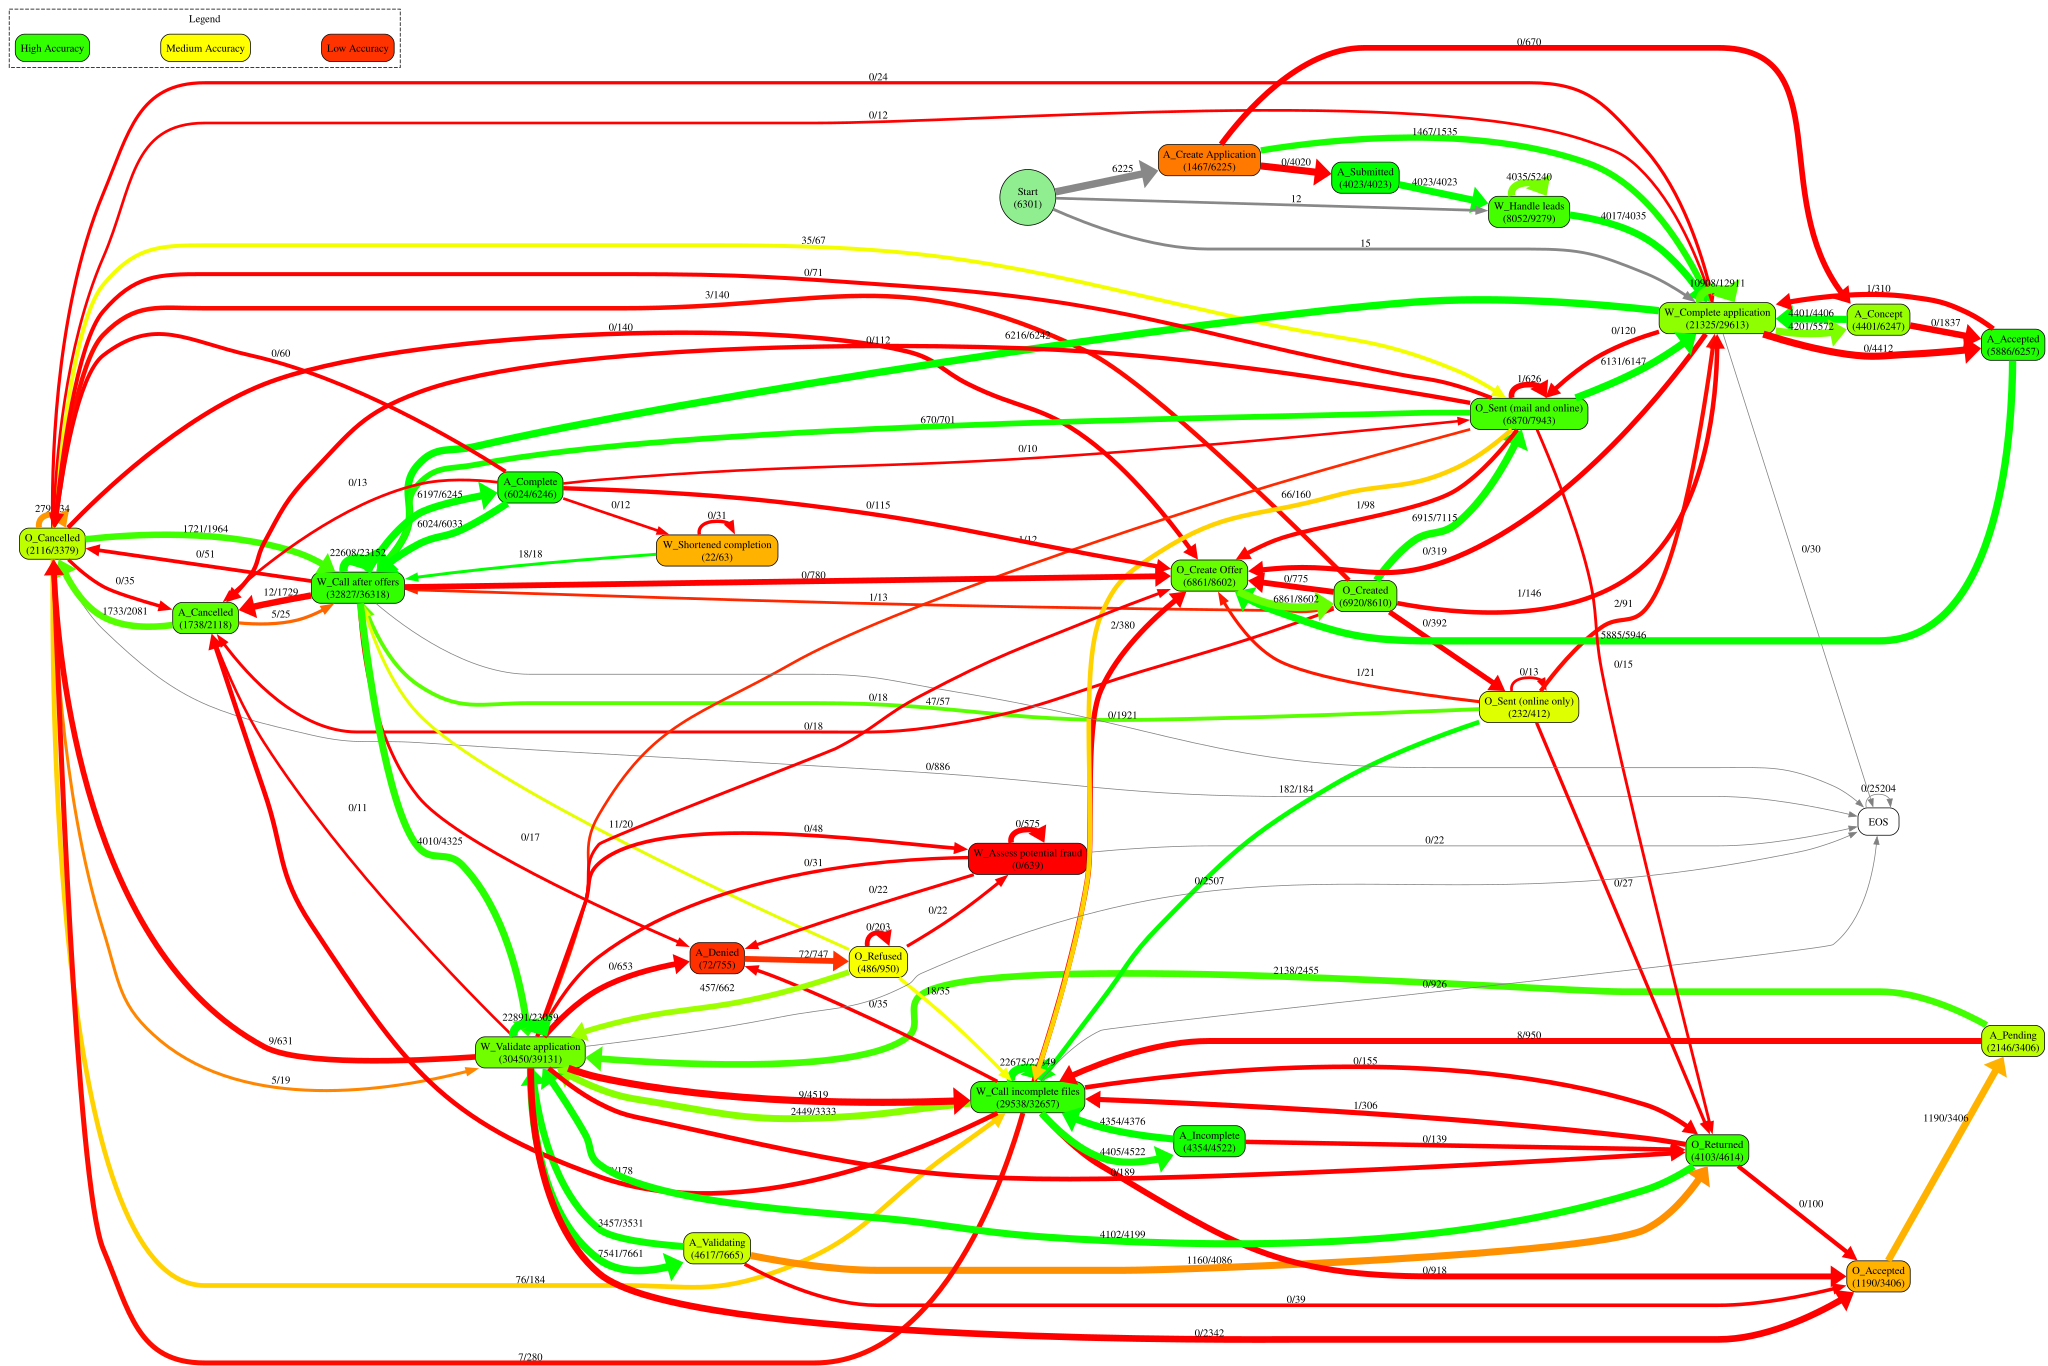

In [ ]:
# ============================================
# FILTERING THRESHOLDS
# ============================================
MIN_EDGE_COUNT = 10       # hide directly-follows edges seen fewer times
MIN_ACTIVITY_COUNT = 10  # hide activities whose total occurrences fall below this

# --- Pre-filter the DFG based on thresholds ---
# Compute per-activity frequency from the DFG
if ppm.dfg is None:
    ppm.mine_dfg()

activity_freq = {}
for (src_act, tgt_act), cnt in ppm.dfg.items():
    activity_freq[src_act] = activity_freq.get(src_act, 0) + cnt
    activity_freq[tgt_act] = activity_freq.get(tgt_act, 0) + cnt

keep_activities = {a for a, c in activity_freq.items() if c >= MIN_ACTIVITY_COUNT}

# Backup original DFG so we can restore it
_original_dfg = dict(ppm.dfg)
ppm.dfg = {
    (s, t): c for (s, t), c in _original_dfg.items()
    if s in keep_activities and t in keep_activities and c >= MIN_EDGE_COUNT
}

n_removed_acts = len(activity_freq) - len(keep_activities)
n_removed_edges = len(_original_dfg) - len(ppm.dfg)
print(f'Filtered out {n_removed_acts} rare activities '
      f'(< {MIN_ACTIVITY_COUNT} occurrences)')
print(f'Filtered out {n_removed_edges} rare directly-follows edges '
      f'(< {MIN_EDGE_COUNT} occurrences)')
print(f'Remaining: {len(keep_activities)} activities, {len(ppm.dfg)} edges')

# Generate process map with filtered DFG
dot = ppm.visualize(
    min_edge_count=MIN_EDGE_COUNT,
    show_counts=True,
    activity_name_map=activity_name_map,
    show_start_node=True,
)

# Restore for any downstream analysis
ppm.dfg = _original_dfg

dot

## Interactive Explorer

In [7]:
# Interactive exploration
explorer = ppm.create_interactive_explorer(activity_name_map=activity_name_map)
explorer.show()